In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm = pd.read_csv("../data/rfm_segments.csv")

X = rfm[["Recency", "Frequency", "Monetary"]].copy()
X["Frequency"] = np.log1p(X["Frequency"])   # log reduces the heavy skew
X["Monetary"] = np.log1p(X["Monetary"])
X_scaled = StandardScaler().fit_transform(X)

X_scaled.shape

(5861, 3)

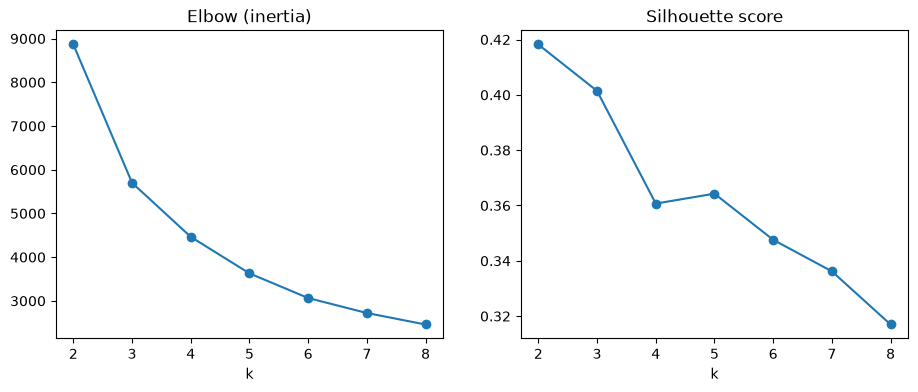

In [10]:
ks = range(2, 9)
inertia, sil = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow (inertia)")
ax[0].set_xlabel("k")
ax[1].plot(ks, sil, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k")
plt.show()

In [11]:
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_scaled)
rfm["Cluster"] = km.labels_
print("silhouette:", round(silhouette_score(X_scaled, km.labels_), 3))

silhouette: 0.361


In [12]:
profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
).round(1)
profile["Revenue_Share_%"] = (profile["Total_Revenue"] / profile["Total_Revenue"].sum() * 100).round(1)
profile.sort_values("Total_Revenue", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
Cluster,,,,,,
2,951,42.5,22.2,12518.5,11905086.5,70.7
1,1877,99.4,5.5,1864.7,3500027.8,20.8
0,1631,493.0,1.7,511.0,833443.7,5.0
3,1402,105.0,1.7,420.0,588867.1,3.5


In [13]:
pd.crosstab(rfm["Segment"], rfm["Cluster"])

Cluster,0,1,2,3
Segment,,,,
At Risk,307,98,1,66
Cant Lose Them,78,235,41,1
Champions,0,696,773,8
Hibernating / Lost,1246,14,0,255
Loyal,0,779,136,297
Need Attention,0,22,0,358
New / Promising,0,33,0,417


In [14]:
rfm.to_csv("../data/rfm_clusters.csv", index=False)

In [15]:
names = {
    2: "VIP Heavy Buyers",
    1: "Regular Repeat Buyers",
    3: "Low-Value Occasional",
    0: "Lapsed Customers",
}
order = ["VIP Heavy Buyers", "Regular Repeat Buyers", "Low-Value Occasional", "Lapsed Customers"]
rfm["ClusterName"] = rfm["Cluster"].map(names)
rfm["ClusterName"].value_counts()

ClusterName
Regular Repeat Buyers    1877
Lapsed Customers         1631
Low-Value Occasional     1402
VIP Heavy Buyers          951
Name: count, dtype: int64

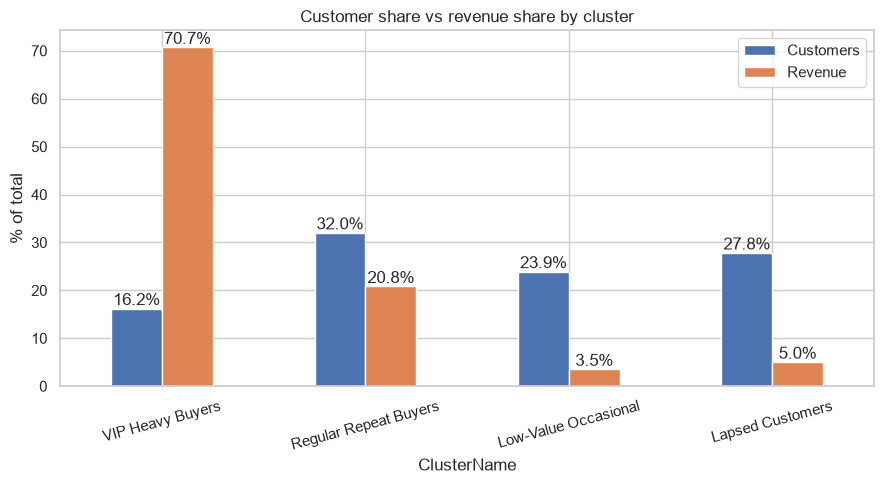

In [16]:
import os
import seaborn as sns
os.makedirs("../images", exist_ok=True)
sns.set_theme(style="whitegrid")

share = rfm.groupby("ClusterName").agg(Customers=("CustomerID", "count"), Revenue=("Monetary", "sum"))
share = (share / share.sum() * 100).round(1).loc[order]

ax = share.plot(kind="bar", figsize=(9, 5), rot=15)
ax.set_ylabel("% of total")
ax.set_title("Customer share vs revenue share by cluster")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("../images/cluster_share.png", dpi=150)
plt.show()

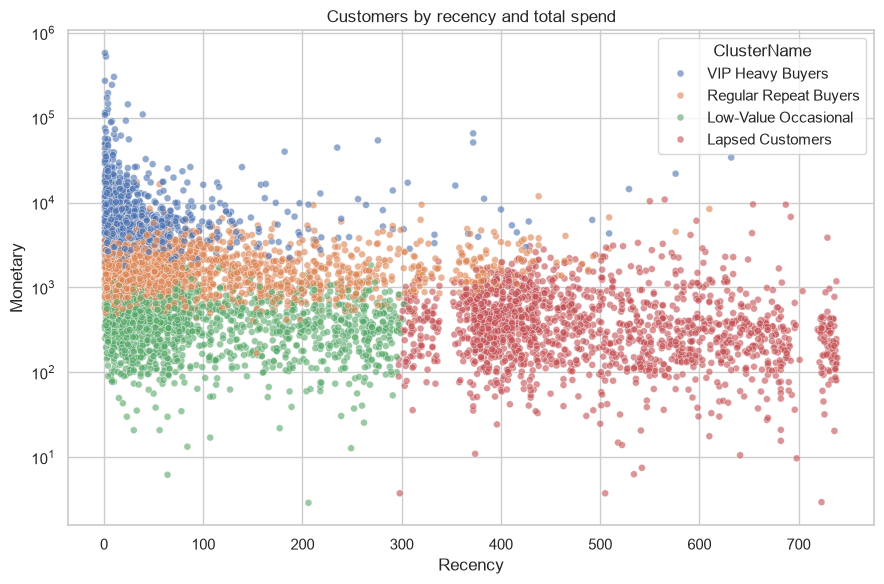

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="ClusterName",
                hue_order=order, alpha=0.6, s=25)
plt.yscale("log")
plt.title("Customers by recency and total spend")
plt.tight_layout()
plt.savefig("../images/cluster_scatter.png", dpi=150)
plt.show()

In [ ]:
rfm.to_csv("../data/rfm_clusters.csv", index=False)

: 